# Initial Data Profiling

Este notebook apresenta uma inspeção inicial automatizada do dataset goodreads utilizando ferramentas de data profiling.

O objetivo desta etapa é identificar rapidamente:

- inconsistências estruturais;
- valores ausentes;
- distribuições;
- possíveis outliers;
- padrões preliminares;
- problemas de qualidade dos dados.

As observações obtidas aqui servirão de apoio para as etapas posteriores de limpeza e análise exploratória detalhada.

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import sweetviz as sv
import matplotlib.pyplot as plt


# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.view.plots as graf
import src.view.tables as tb

---

## Carregando Dados

In [2]:
caminho = '../../data/raw/books/Goodreads_books_with_genres.csv'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='csv')

Dados CSV carregados! Formato: (11127, 13)


- - - 

## Exploração Inicial - Visão Geral

In [3]:
print("Estrutura do DataFrame:\n")
df_books.info()

Estrutura do DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Book Id             11127 non-null  int64  
 1   Title               11127 non-null  object 
 2   Author              11127 non-null  object 
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  object 
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  object 
 7   num_pages           11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  object 
 11  publisher           11127 non-null  object 
 12  genres              11030 non-null  object 
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


In [4]:
print("Dados de amostra:\n")
df_books.head()

Dados de amostra:



,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve..."


---
## Geração do relatório

                                             |          | [  0%]   00:00 -> (? left)


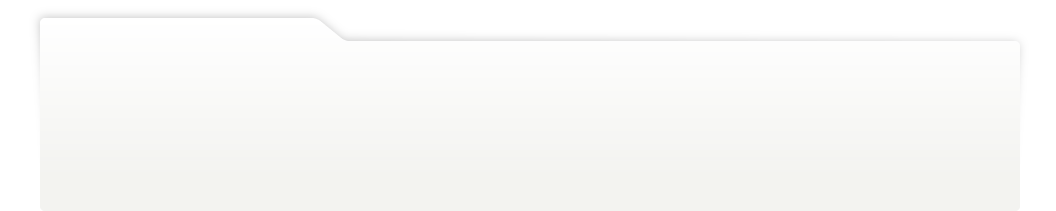
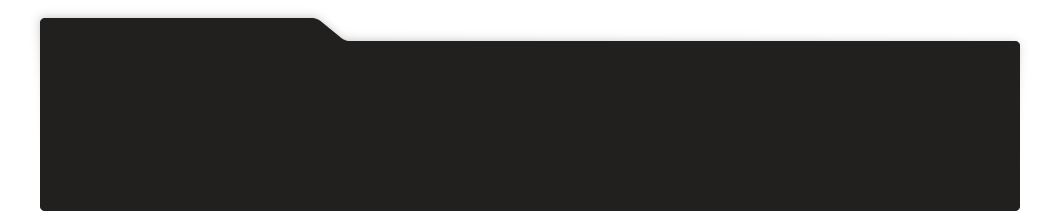
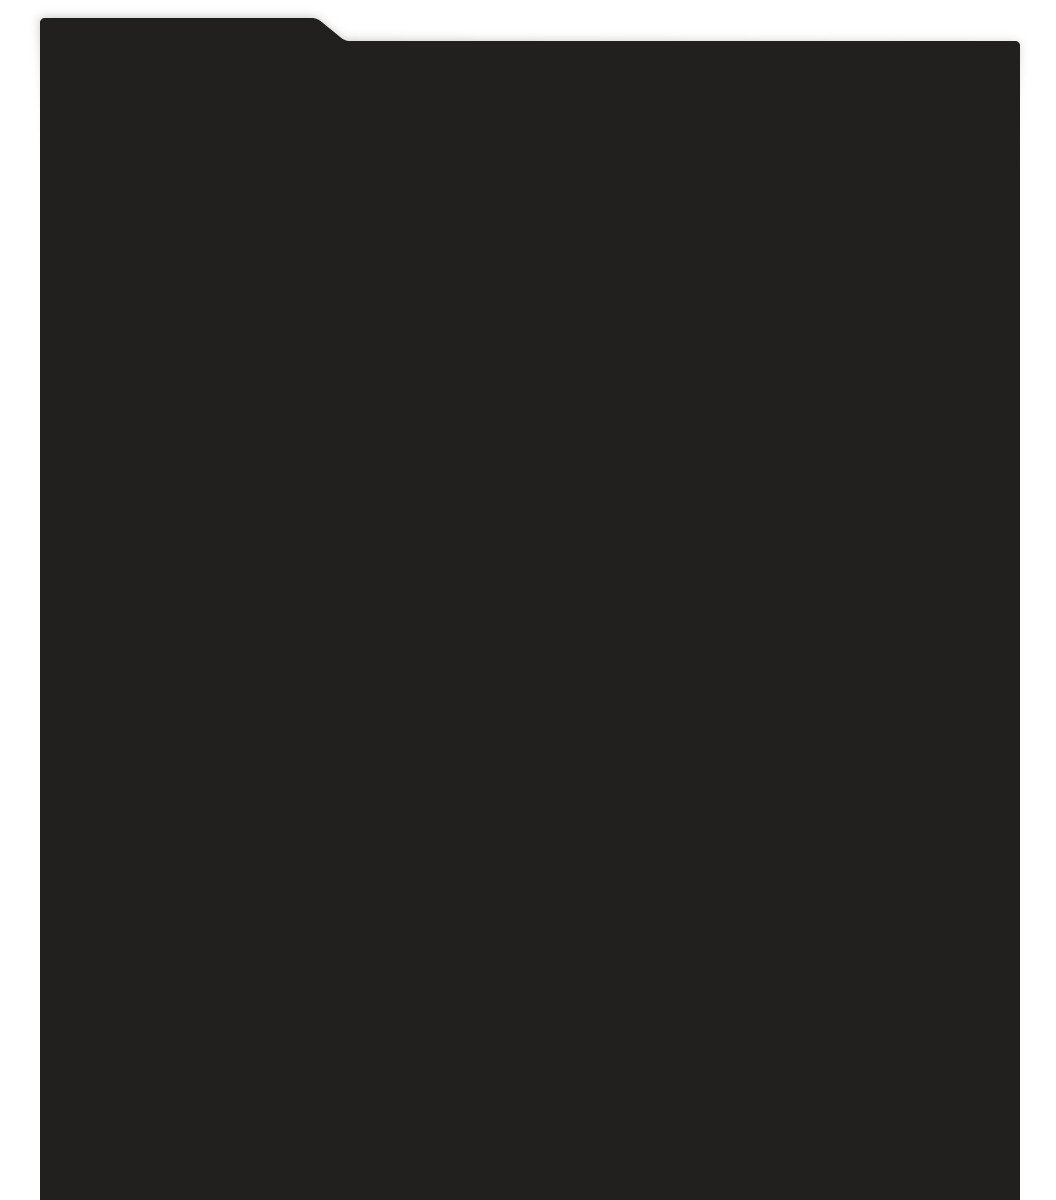
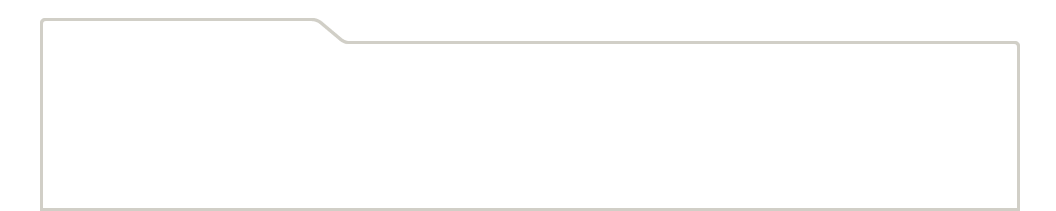
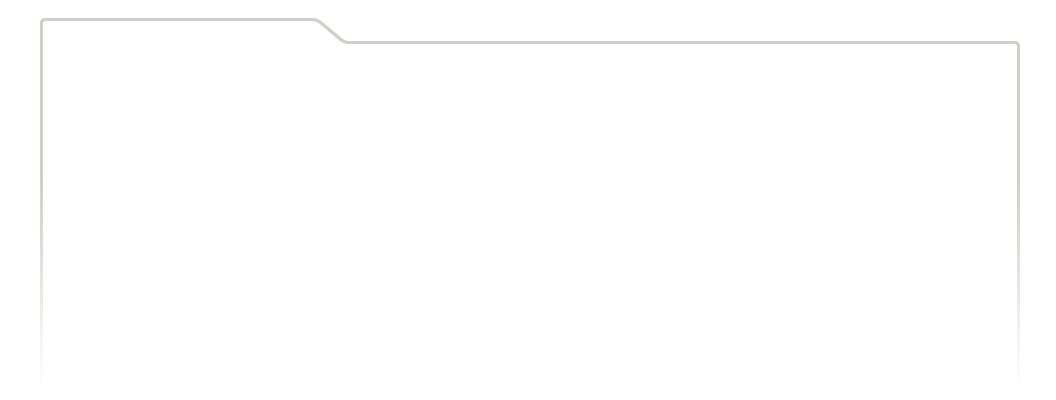
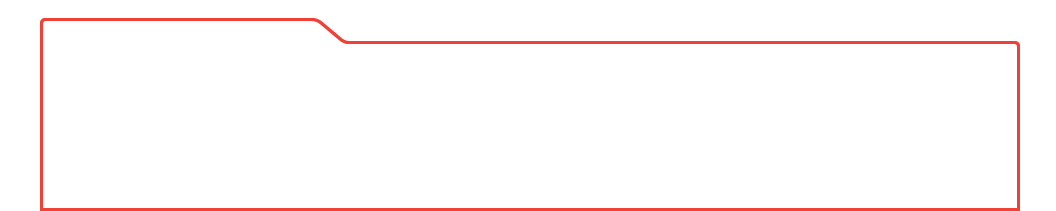
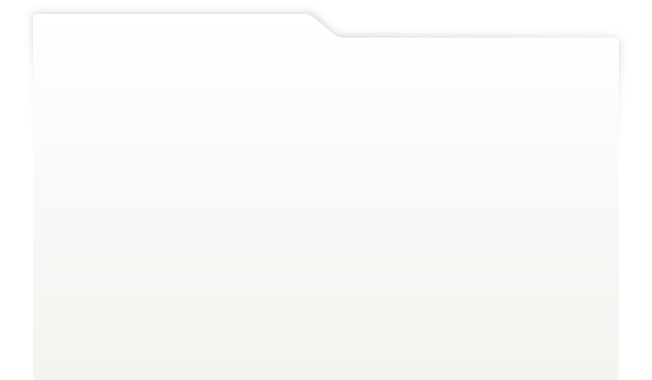
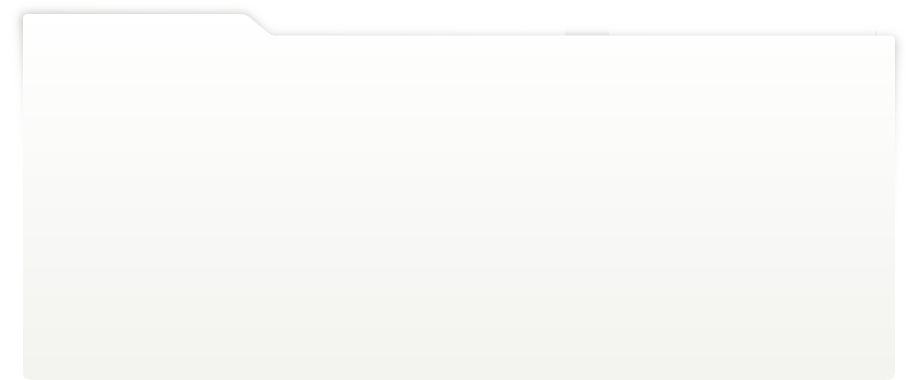
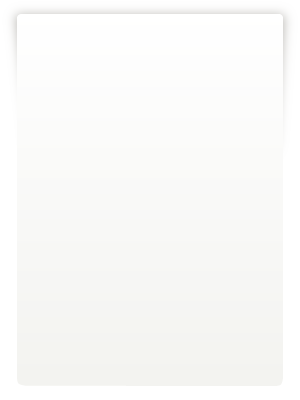
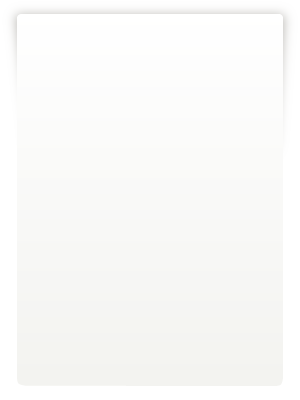
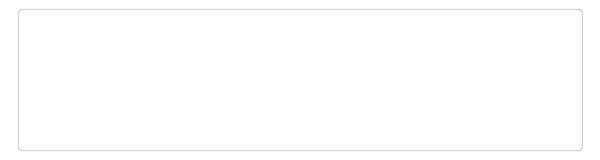
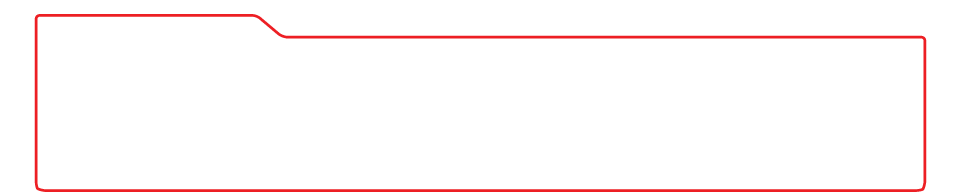
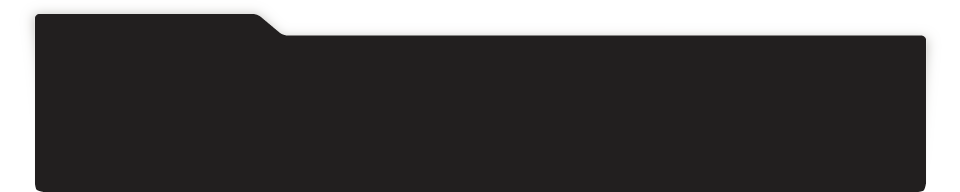
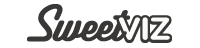
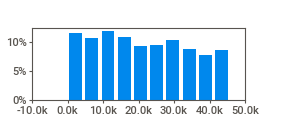
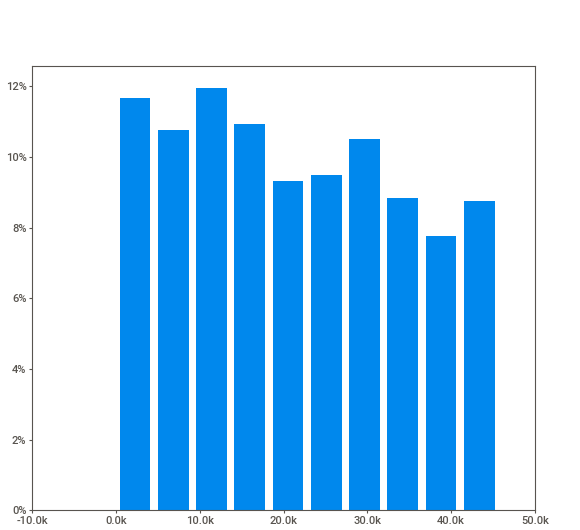
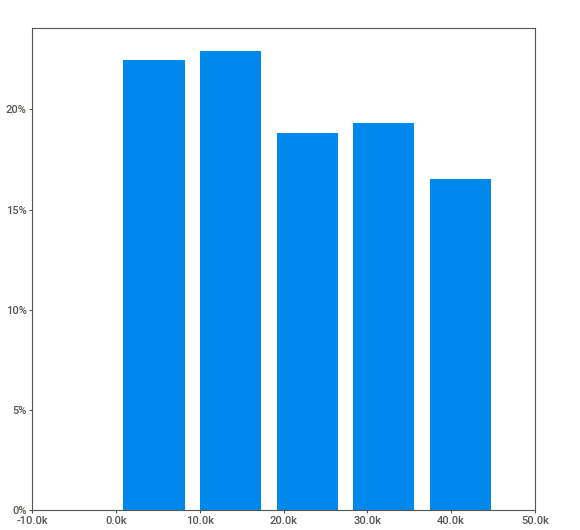
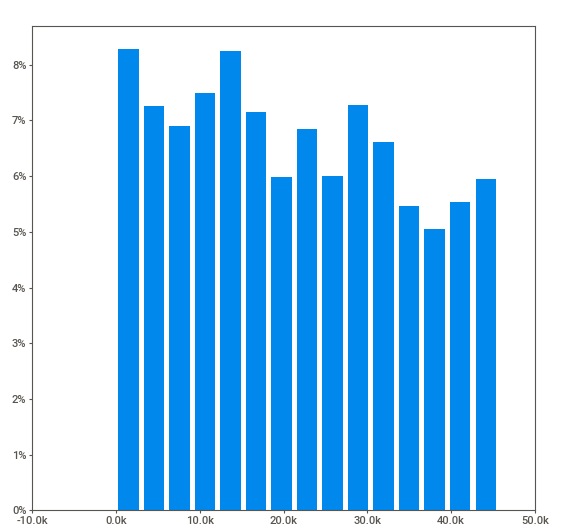
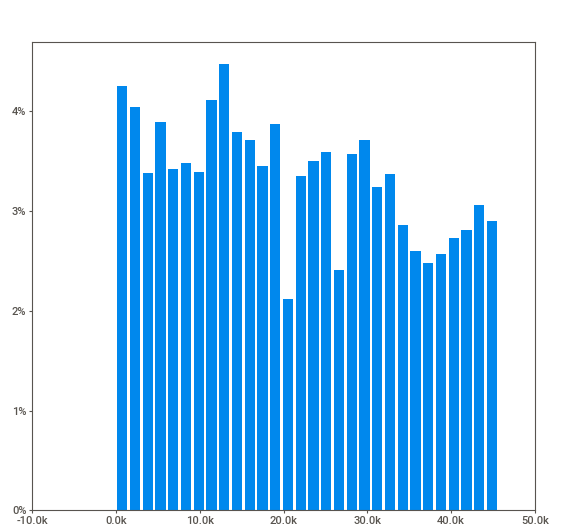
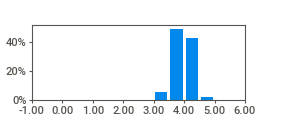
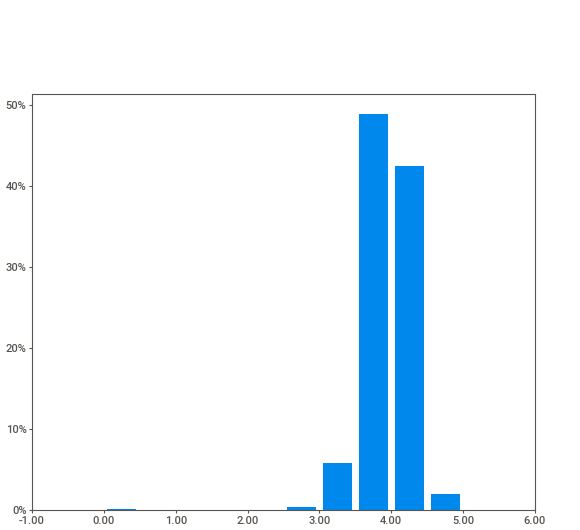
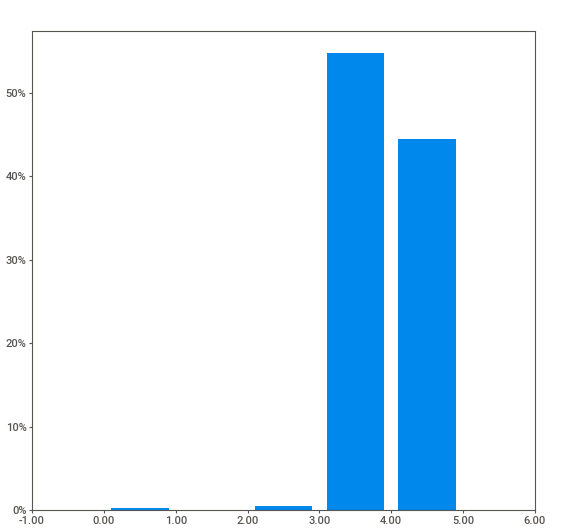
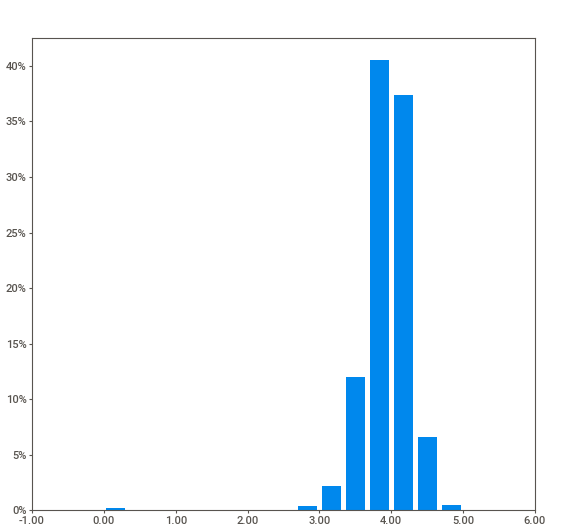
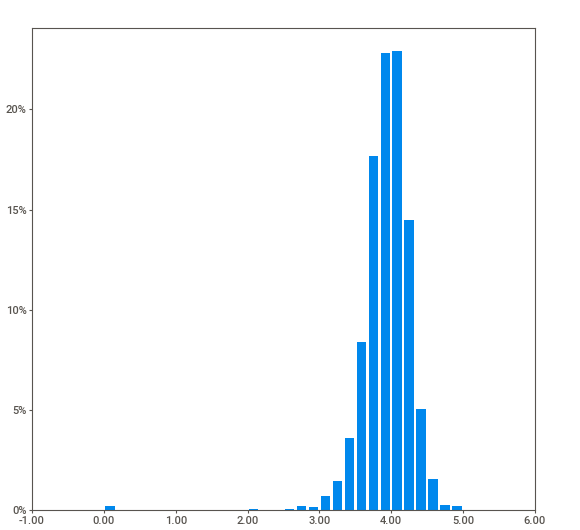
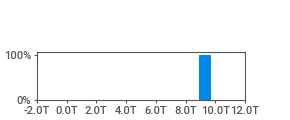
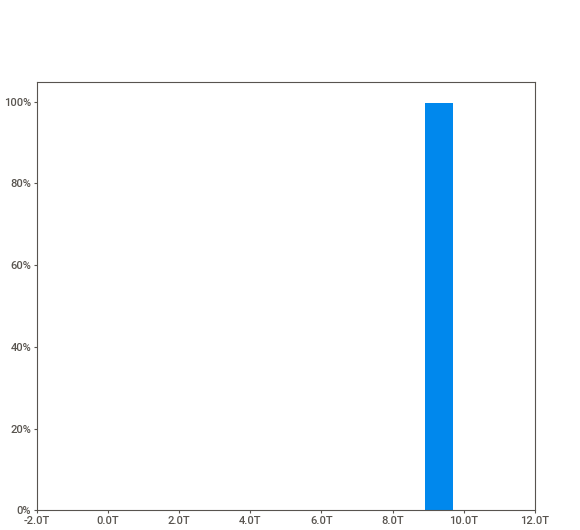
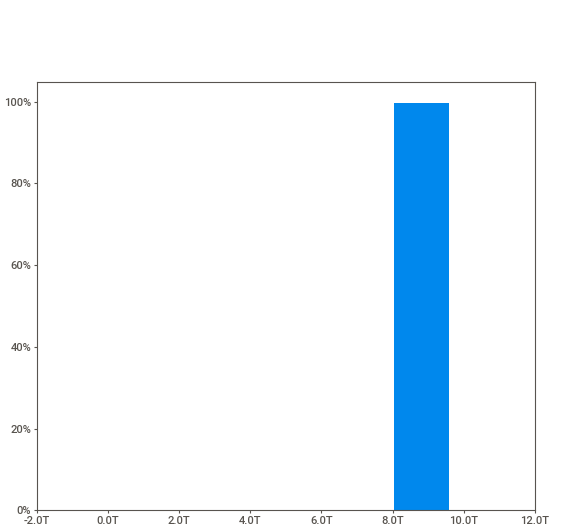
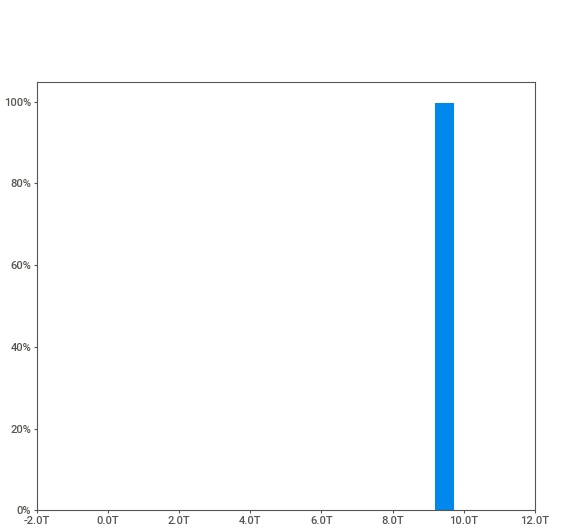
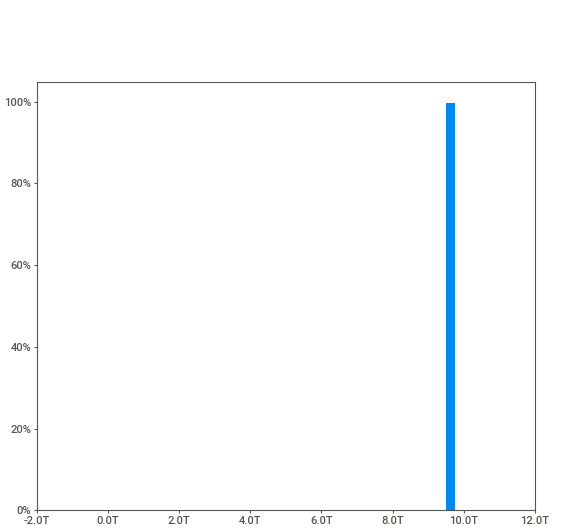
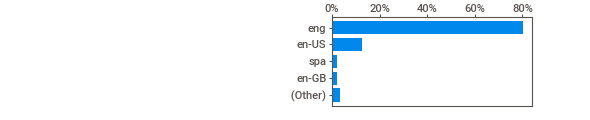
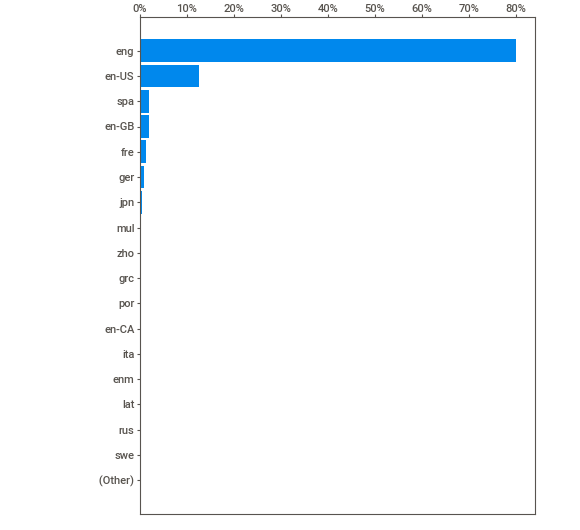
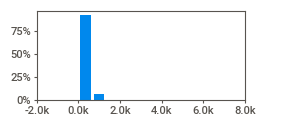
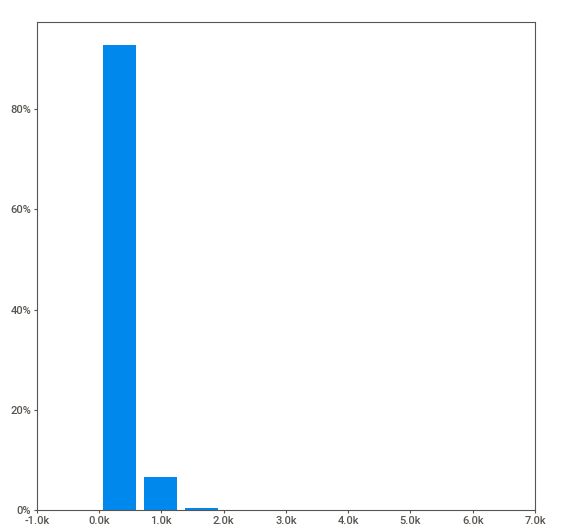
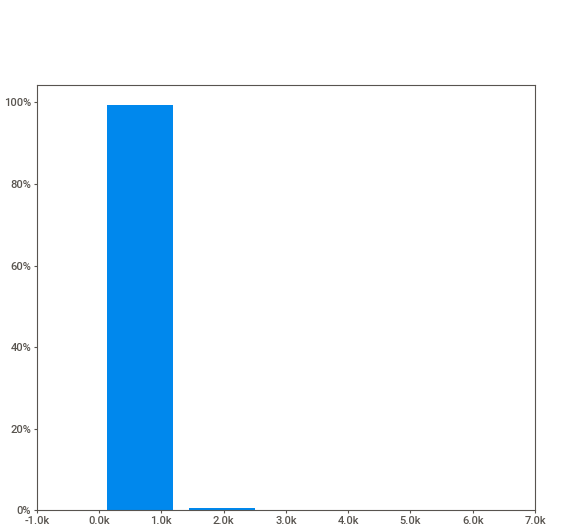
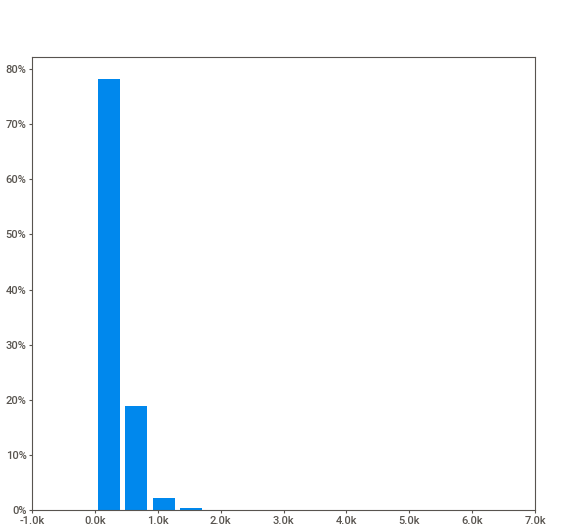
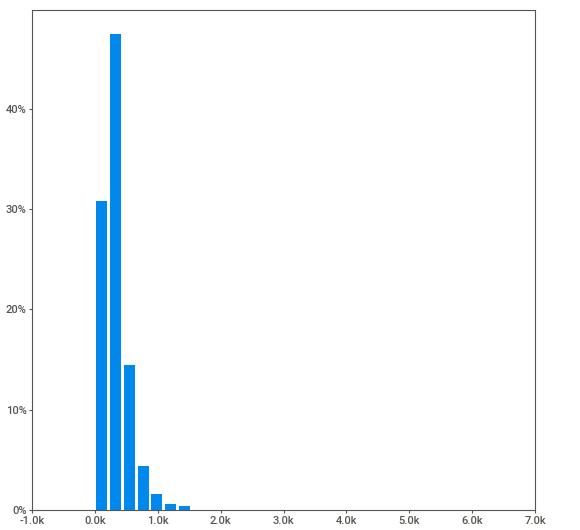
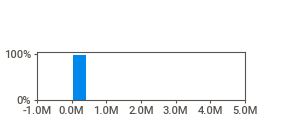
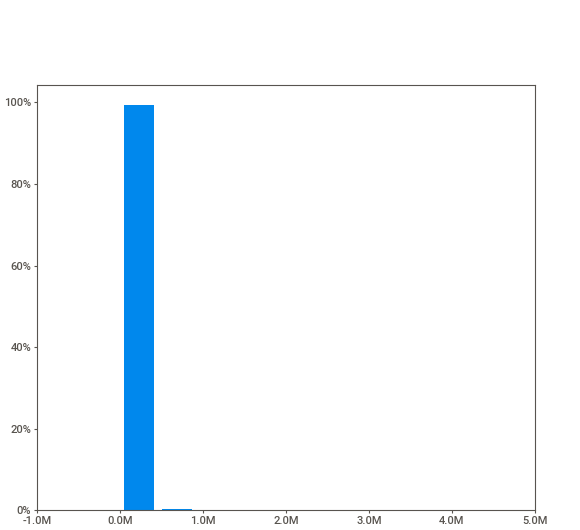
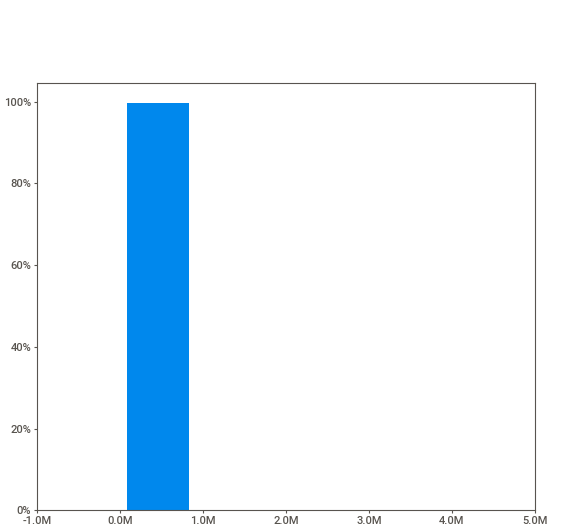
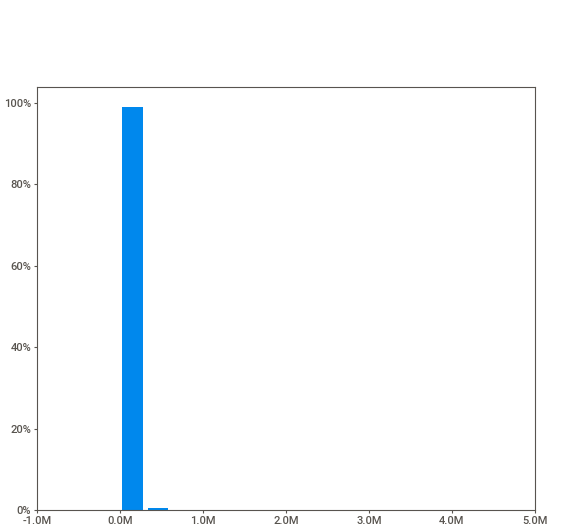
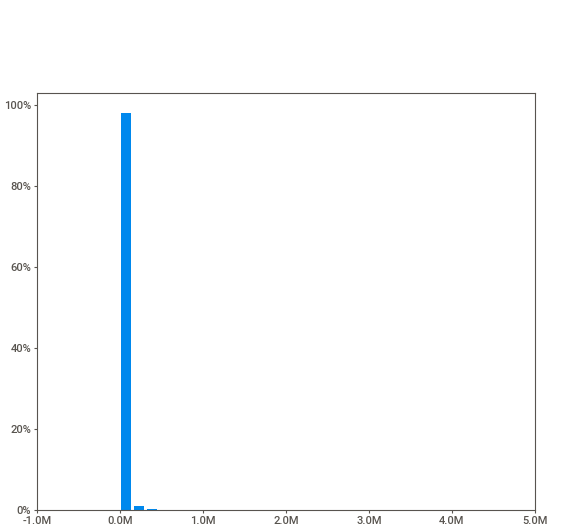
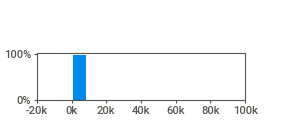
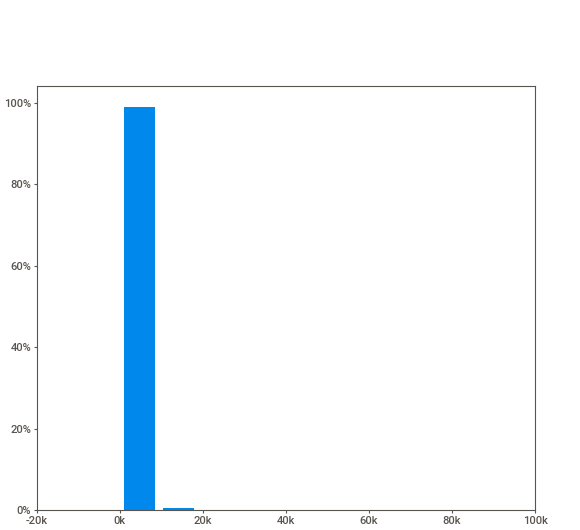
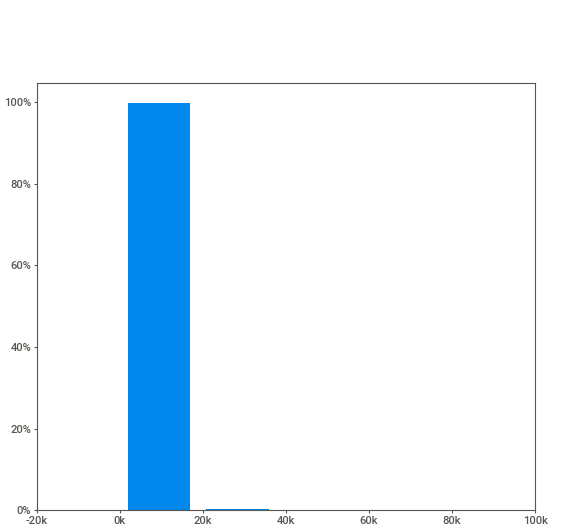
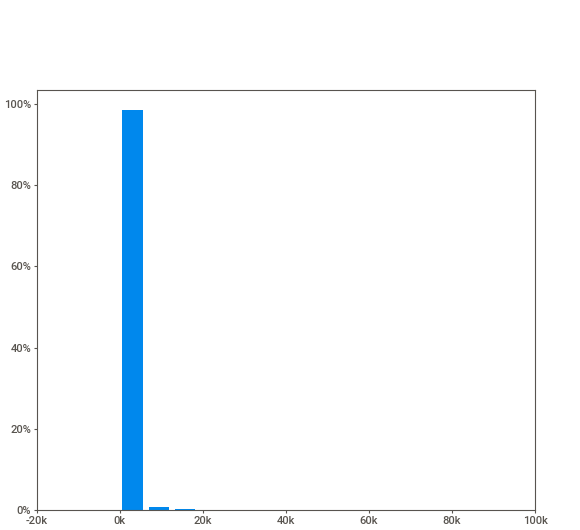
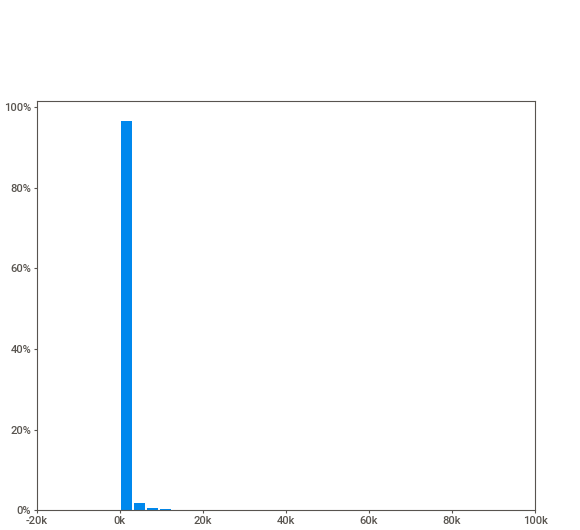
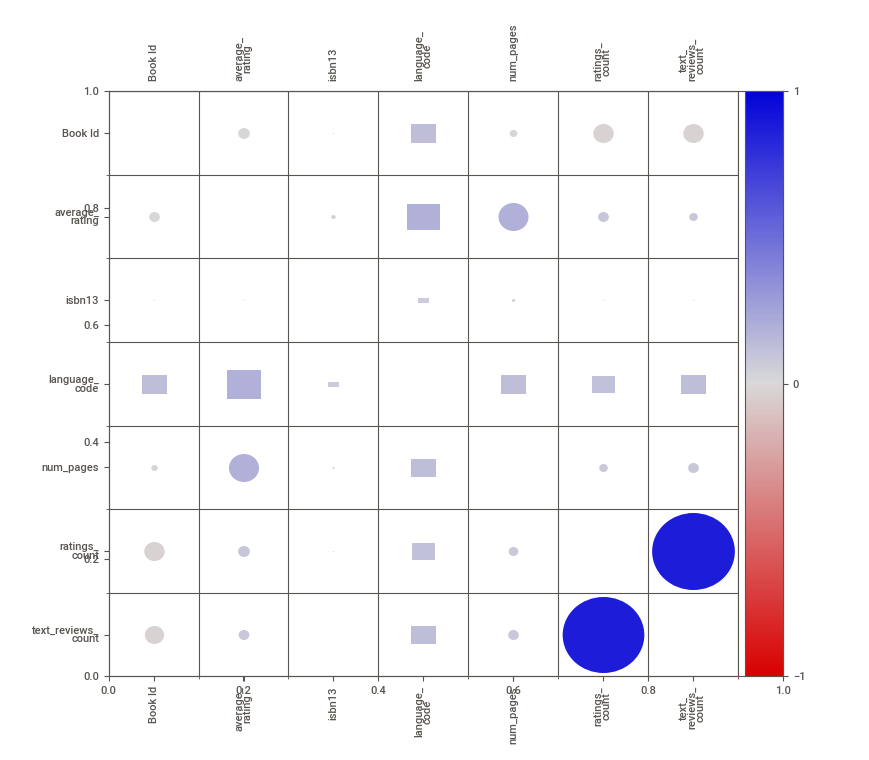
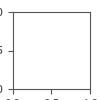

In [5]:
report = sv.analyze(df_books)

report.show_notebook()

- - - 

## Estruturação e Tipagem de Dados (Data Casting)

In [6]:
display(tb.estilizar_tabela(
    df=df_books['genres'].to_frame(name='genres'),
    qtd_linhas=5,
    caption="Exibindo os primeiros 5 valores da coluna 'genres:'"
))

,genres
0,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Childrens;Adventure;Audiobook;Childrens,Middle Grade;Classics;Science Fiction Fantasy"
1,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Childrens;Adventure;Audiobook;Childrens,Middle Grade;Classics;Science Fiction Fantasy"
2,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Childrens;Childrens,Middle Grade;Audiobook;Adventure;Classics;Science Fiction Fantasy"
3,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Childrens;Childrens,Middle Grade;Adventure;Audiobook;Classics;Science Fiction Fantasy"
4,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adventure;Fantasy,Supernatural;Mystery;Childrens;Fantasy,Paranormal;Childrens,Middle Grade"


In [7]:
df_books['publication_date'].head()

0    9/16/2006
1     9/1/2004
2    11/1/2003
3     5/1/2004
4    9/13/2004
Name: publication_date, dtype: object

In [8]:
display(tb.estilizar_tabela(
    df=df_books['isbn'].to_frame(),
    qtd_linhas=10
))

,isbn
0,0439785960
1,0439358078
2,0439554896
3,043965548X
4,0439682584
5,0976540606
6,0439827604
7,0517226952
8,0345453743
9,1400052920


In [9]:
display(tb.estilizar_tabela(
    df_books['isbn13'].to_frame(),
    qtd_linhas=10
))

,isbn13
0,9780439785969
1,9780439358071
2,9780439554893
3,9780439655484
4,9780439682589
5,9780976540601
6,9780439827607
7,9780517226957
8,9780345453747
9,9781400052929


## Estruturação, Normalização e Criação de Features Globais
A coluna genres encontra-se atualmente tipada como object (string), armazenando os dados em um formato inadequado para consultas relacionais.

### Observações Identificadas:

- Baixa Granularidade: Os dados não estão atomizados. Um único registo de livro contém diversos géneros literários agrupados na mesma célula.

- Delimitador Estrutural: Os valores individuais dentro da string bruta estão sistematicamente separados pelo caractere de ponto e vírgula (;).

- Padronização: A coluna `Title` destaca-se por começar com letra maiúscula, fazendo com que destoe das demais colunas tanto deste, quanto dos outros datasets deste projeto. De forma semelhante, a coluna `Book Id` também receberá nova roupagem, tornando-se assim `book_id`.

- Identificadores Redundantes: As colunas isbn e isbn13 representam o International Standard Book Number. Ambas atuam como chaves alternativas de identificação única para a mesma obra. O isbn13 é essencialmente uma extensão do padrão original, gerando uma redundância de dados diretos no dataset.

- Incompatibilidade de Esquema: As escalas de notas (que vão até 5) e a nomenclatura de certas colunas divergem do padrão do dataset de filmes.

### Decisão e Tratamento:
Para adequar os dados ao padrão de modelagem relacional, a coluna passará por um processo de refatoração estrutural. O texto contínuo será inicialmente fatiado (split) com base no delimitador, convertendo a string numa estrutura de lista. Em seguida, será aplicada a operação de explosão (explode), que desmembrará a lista, alocando cada género numa linha individual. Modificar a coluna `Title` para `title` uniformizando o schema entre os datasets.

Essa transformação garantirá o nível de granularidade correto, permitindo a criação de uma relação eficiente e escalável do tipo Muitos-para-Muitos (N:M) entre os livros e as suas respetivas tags de género.

Vale ressaltar que a harmonização universal das colunas e a padronização das notas serão executadas na etapa de Engenharia de Features. Adicionalmente, esta fase contemplará a criação de **Features Globais** analíticas (como a idade da obra, agrupamento por décadas, taxa de engajamento anual e quadrantes de popularidade). Estas novas variáveis permitirão nivelar as métricas de sucesso, viabilizando uma comparação justa e estruturada do comportamento do público face a diferentes épocas e formatos.

---
## Análise de Valores Nulos e Anomalias de Plataforma

Análisando valores nulos nas nossas *features* para evitar que os *missing data`s* sejam um problema na análise final do nosso dataset e puxem nossa médias de notas para baixo ou deixem livros sem classificação de gênero e tropo (tropes). 

In [10]:
df_resumo_nulos_books = dq.resumo_qualidade(df_books)

# Aplicar um gradiente de cor (vermelho para os mais críticos)
display(tb.estilizar_resumo_qualidade(
    df_resumo_nulos_books,
    col_quantidade='Quantidade (Nulos/Zeros)',
    col_percentual='Perda de Dados (%)',
    caption="Diagnóstico de Zeros — Goodreads Dataset"
))

,Quantidade,Perda de Dados (%)
text_reviews_count (Zeros - Numérico),625,5.62%
genres (Valores NaN),97,0.87%
ratings_count (Zeros - Numérico),81,0.73%
num_pages (Zeros - Numérico),76,0.68%
average_rating (Zeros - Numérico),26,0.23%
publication_date (Valores NaT),2,0.02%


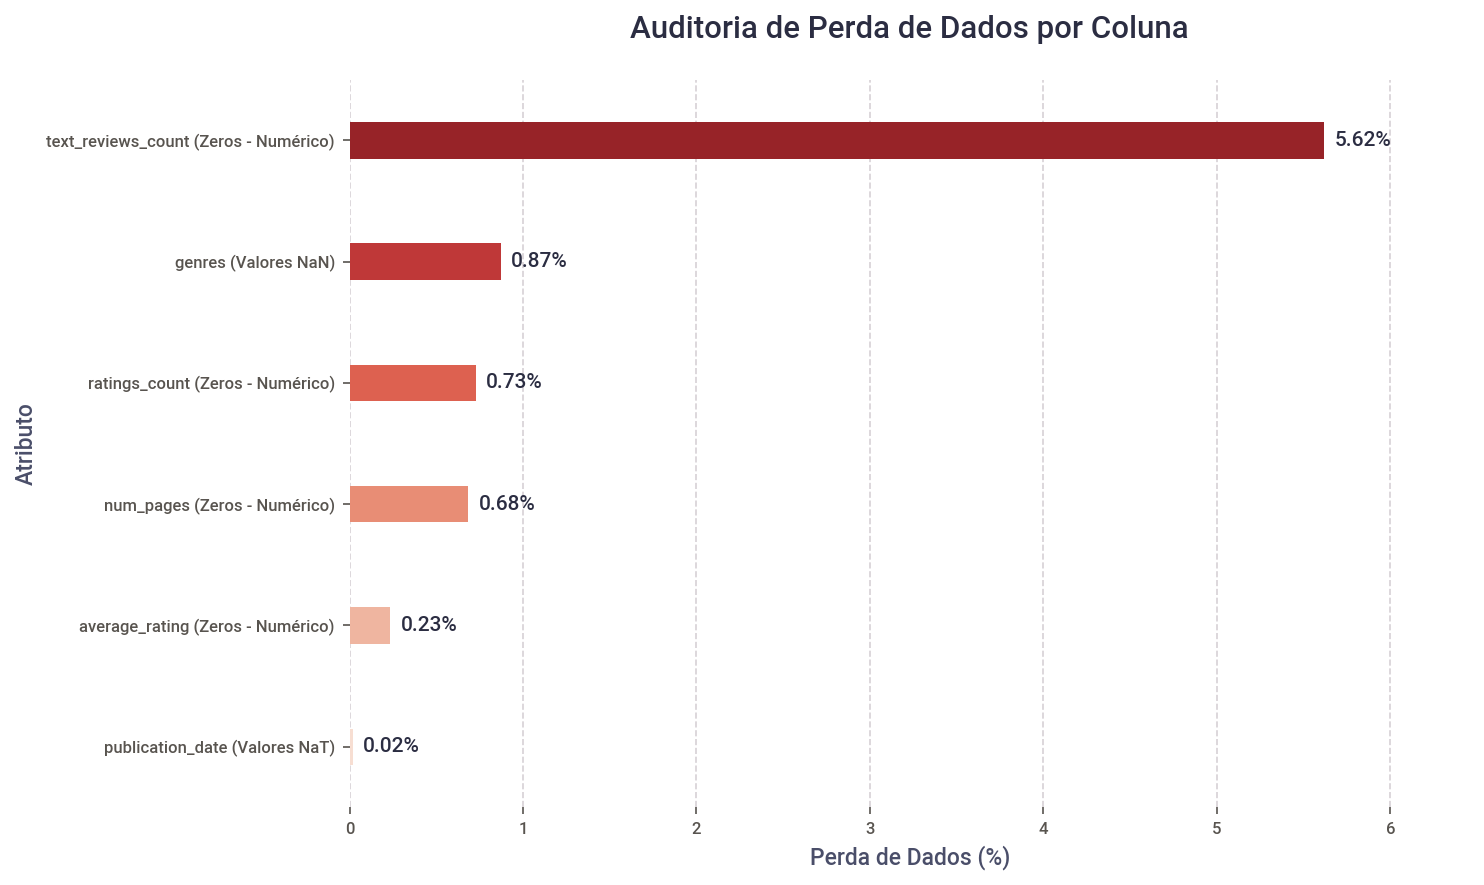

In [11]:
graf.grafico_percentual_missing_data(
    df_plot=df_resumo_nulos_books, 
    tamanho_figura=(10,6), 
    polegadas=150, 
    width=0.3
)

In [12]:
display(
    tb.destacar_anomalias(
        df_books,
        mascara=(df_books['genres'].isnull()),
        colunas_destaque=['genres'],
        colunas_contexto=['Title', 'Author', 'average_rating', 'ratings_count'],
        qtd_linhas=5,
        caption='Livros sem genêro'
    )
)

,Title,Author,average_rating,ratings_count,genres
31,Molly Hatchet - 5 of the Best,Molly Hatchet,4.33,6,nan
201,Timbuktu / Leviathan / Moon Palace,Paul Auster,4.38,21,nan
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.14,1,nan
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.00,0,nan
306,The 5 Love Languages / The 5 Love Languages Journal,Gary Chapman,4.70,22,nan


In [13]:
# Top Autores entre os nulos
display(
    tb.estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['Author'].value_counts().to_frame(name='contagem'),
        qtd_linhas=10,
        caption="Top 10 Autores com mais livros sem gênero"
    )
)

,contagem
Author,
NOT A BOOK,4
Debra Hess,3
Roger Hargreaves/Gray Jolliffe,2
Karen O'Connor/Larry J. Sabato,2
Mary B. Collins,2
Carl Hiaasen/Edward Asner,2
Gary Chapman,1
Molly Hatchet,1
Cynthia W. Shelmerdine,1


In [14]:
display(tb.destacar_anomalias(
    df_books,
    mascara=(df_books['Author'] == 'NOT A BOOK'),
    colunas_destaque=['Author'],
    colunas_contexto=['Title', 'genres'],
    caption="Anomalia: Livros Registrados como 'NOT A BOOK"
))

,Title,genres,Author
1061,Murder by Moonlight & Other Mysteries (New Adventures of Sherlock Holmes 19-24),nan,NOT A BOOK
1064,The Unfortunate Tobacconist & Other Mysteries (Sherlock Holmes 1-6),nan,NOT A BOOK
5476,The Goon Show Volume 4: My Knees Have Fallen Off!,nan,NOT A BOOK
5477,The Goon Show: Moriarty Where Are You?,Humor,NOT A BOOK
5478,The Goon Show Volume 11: He's Fallen in the Water!,nan,NOT A BOOK


In [15]:
# Distribuição do Total de Avaliações (ratings_count)
display(
    tb.estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['ratings_count'].value_counts().to_frame(name='contagem'),
        qtd_linhas=5,
        caption="Contagem de avaliações mais comuns nos nulos"
    )
)

,contagem
ratings_count,
0,16
1,9
5,9
4,8
2,6


In [16]:
# Distribuição das Notas Médias (average_rating)
display(
    tb.estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['average_rating'].value_counts().to_frame(name='contagem'),
        qtd_linhas=5,
        caption="Notas médias mais comuns nos livros sem gênero"
    )
)

,contagem
average_rating,
4.000000,13
0.000000,11
5.000000,7
3.600000,5
4.500000,4


In [17]:
# Top Editoras entre os nulos
display(
    tb.estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['publisher'].value_counts().to_frame(name='contagem'),
        qtd_linhas=5,
        caption="Top Editoras com livros sem gênero"
    )
)

,contagem
publisher,
Cliffs Notes,5
Routledge,3
Cavendish Square Publishing,3
BBC Physical Audio,3
Random House Audio,2


In [18]:
#  Amostra das datas de publicação (usando colchetes duplos para retornar DataFrame direto)
display(
    tb.estilizar_tabela(
        df=df_books[df_books['genres'].isnull()][['publication_date']],
        qtd_linhas=10,
        caption="Amostra de datas de publicação (Livros sem gênero)"
    )
)

,publication_date
31,6/10/2003
201,11/7/2002
217,1/1/1989
265,9/1/2001
306,1/1/2005
362,2/10/2006
392,9/1/1998
441,1/30/1989
463,9/13/1965
507,12/29/1983


In [19]:
# Contagem e Porcentagem de Idiomas entre os livros sem gênero
display(
    tb.estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['language_code'].value_counts().to_frame(name='contagem'),
        qtd_linhas=10,
        caption="Top 10 Idiomas nos livros sem gênero"
    )
)

display(
    tb.estilizar_tabela(
        df=(df_books[df_books['genres'].isnull()]['language_code'].value_counts(normalize=True) * 100).to_frame(name='porcentagem'),
        qtd_linhas=10,
        caption="Porcentagem de cada idioma entre os nulos"
    )
)

,contagem
language_code,
eng,84
en-US,6
spa,2
fre,1
ger,1
srp,1
grc,1
wel,1


,porcentagem
language_code,
eng,86.60%
en-US,6.19%
spa,2.06%
fre,1.03%
ger,1.03%
srp,1.03%
grc,1.03%
wel,1.03%


In [20]:
display(
    tb.estilizar_tabela(
        df=(df_books['language_code'].value_counts() / len(df_books) * 100).to_frame(name='porcentagem'),
        qtd_linhas=10,
        caption="Porcentagem de cada idioma entre os livros"
    )
)

,porcentagem
language_code,
eng,80.08%
en-US,12.66%
spa,1.96%
en-GB,1.92%
fre,1.29%
ger,0.89%
jpn,0.41%
mul,0.17%
zho,0.13%


In [21]:
display(tb.destacar_anomalias(
    df_books,
    mascara=(df_books['average_rating'] == 0),
    colunas_destaque=['average_rating'],
    colunas_contexto=['Title', 'Author', 'ratings_count', 'text_reviews_count'],
    caption="Anomalia: Livros com Avaliação Média Igual a Zero"
))

nota_zero = (df_books['average_rating'] == 0).sum()
print(f"\nTotal de livros com avaliação média igual a zero: {nota_zero}")

,Title,Author,ratings_count,text_reviews_count,average_rating
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0,0,0.00
375,Juiced Official Strategy Guide,Doug Walsh,0,0,0.00
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbeck/Michael Cunningham/Deborah Garrison/Rem Koolhaas/Rick Moody/Strawberry Saroyan/Debra Garrison,0,0,0.00
2532,"How To Meditate: An Anthology Of Talks On Meditation And ""Meditation: The Bridge Is Flowing But The River Is Not",Frederick P. Lenz,0,0,0.00
2533,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,0,0,0.00
2758,Venac sonetnih venaca; Puževa srma,Dobrica Erić,0,0,0.00
3493,Brodie's notes on Aldous Huxley's brave new world,Graham Handley,0,0,0.00
4242,American Film Guide,Frank N. Magill,0,0,0.00
4678,The Man and the Author: John Milton: Twentieth Century Perspectives,J. Martin Evans,0,0,0.00
5325,Canopy: A Work for Voice and Light in Harvard Yard,David Ward/Parveen Adams/Seamus Heaney/Ivan Gaskell,0,0,0.00



Total de livros com avaliação média igual a zero: 26


In [22]:
display(tb.destacar_anomalias(
    df_books,
    mascara=(df_books['ratings_count'] == 0),
    colunas_destaque=['ratings_count'],
    colunas_contexto=['Title', 'Author', 'average_rating', 'text_reviews_count'],
    caption="Anomalia: Livros sem Nenhuma Avaliação"
))

n_nota_zero = (df_books['ratings_count'] == 0).sum()
print(f"\nTotal de livros com 0 avaliações: {n_nota_zero}")

,Title,Author,average_rating,text_reviews_count,ratings_count
264,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,4.03,0,0
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.00,0,0
375,Juiced Official Strategy Guide,Doug Walsh,0.00,0,0
525,American Government: Continuity and Change Alternate Edition,Karen O'Connor/Larry J. Sabato,2.83,0,0
526,Essentials of American and Texas Government: Continuity and Change,Karen O'Connor/Larry J. Sabato,3.50,0,0
624,Comoediae 1: Acharenses/Equites/Nubes/Vespae/Pax/Aves,Aristophanes/F.W. Hall/W.M. Geldart,5.00,0,0
747,Melville and the politics of identity: From *King Lear* to *Moby-Dick*,Julian Markels,3.33,0,0
935,April May und June,Elizabeth von Arnim,3.88,0,0
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbeck/Michael Cunningham/Deborah Garrison/Rem Koolhaas/Rick Moody/Strawberry Saroyan/Debra Garrison,0.00,0,0
1110,Dr No / Moonraker / Thunderball / From Russia with Love / On Her Majesty's Secret Service / Goldfinger,Ian Fleming,3.98,0,0



Total de livros com 0 avaliações: 81


In [23]:
display(tb.destacar_anomalias(
    df_books,
    mascara=(df_books['text_reviews_count'] == 0),
    colunas_destaque=['text_reviews_count'],
    colunas_contexto=['Title', 'Author', 'average_rating', 'ratings_count'],
    qtd_linhas=10,
    caption="Anomalia: Livros sem Nenhuma Avaliação"
))


n_reviews_zero = (df_books['text_reviews_count'] == 0).sum()
print(f"\nTotal de livros com 0 avaliações: {n_reviews_zero}")

,Title,Author,average_rating,ratings_count,text_reviews_count
31,Molly Hatchet - 5 of the Best,Molly Hatchet,4.33,6,0
77,The Power of One: The Solo Play for Playwrights Actors and Directors,Louis E. Catron,3.67,10,0
80,What to Sell on ebay and Where to Get It: The Definitive Guide to Product Sourcing for eBay and Beyond,Chris Malta/Lisa Suttora,3.62,24,0
82,eBay: Top 100 Simplified Tips & Tricks,Julia Wilkinson,4.27,9,0
102,Dalit: The Black Untaouchables of India,V.T. Rajshekar/Y.N. Kly,4.20,10,0
104,The Evidence-Based Social Work Skills Book,Barry R. Cournoyer,3.40,10,0
105,"A Wrinkle in Time: A Guide for Using ""A Wrinkle in Time"" in the Classroom",John Carratello/Patty Carratello/Theresa Wright,4.00,17,0
108,Literature Circle Guide: A Wrinkle in Time,Tara MacCarthy,3.60,15,0
160,Salmon of Doubt: Hitchhiking the Galaxy One Last Time,Douglas Adams/Christopher Cerf,3.93,5,0
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.14,1,0



Total de livros com 0 avaliações: 625


In [24]:
mask = (
    (df_books['text_reviews_count'] >= 1) &
    (df_books['average_rating'] == 0.00)
)

display(tb.destacar_anomalias(
    df_books,
    mascara=mask,
    colunas_destaque=['text_reviews_count'],
    colunas_contexto=['Title', 'Author', 'ratings_count', 'average_rating', 'genres'],
    caption='Anomalia: Reviws exitindo mesmo sem notas médias'
))

,Title,Author,ratings_count,average_rating,genres,text_reviews_count
10142,Day and Night,Better Homes and Gardens,0,0.00,Juvenile Nonfiction,1


In [25]:
mask = (
    (df_books['average_rating'] == 0) &
    (df_books['ratings_count'] == 0) &
    (df_books['text_reviews_count'] == 0)
)

n_livros_zero = mask.sum()

display(
    tb.destacar_anomalias(
    df_books,
    mascara=mask,
    colunas_destaque=['text_reviews_count', 'ratings_count', 'average_rating' ],
    colunas_contexto=['Title', 'Author', 'genres'],
    caption='Anomalia: Notas Médias Zeradas, Número de Notas Zerado e Número de Reviews Zerado'
))
print(f"\nTotal de livros com avaliação média, contagem de avaliações e contagem de avaliações de texto iguais a zero: {n_livros_zero}")


,Title,Author,genres,text_reviews_count,ratings_count,average_rating
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,nan,0,0,0.00
375,Juiced Official Strategy Guide,Doug Walsh,Games;Activities,0,0,0.00
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbeck/Michael Cunningham/Deborah Garrison/Rem Koolhaas/Rick Moody/Strawberry Saroyan/Debra Garrison,nan,0,0,0.00
2532,"How To Meditate: An Anthology Of Talks On Meditation And ""Meditation: The Bridge Is Flowing But The River Is Not",Frederick P. Lenz,nan,0,0,0.00
2533,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,Spiritual life,0,0,0.00
2758,Venac sonetnih venaca; Puževa srma,Dobrica Erić,nan,0,0,0.00
3493,Brodie's notes on Aldous Huxley's brave new world,Graham Handley,nan,0,0,0.00
4242,American Film Guide,Frank N. Magill,nan,0,0,0.00
4678,The Man and the Author: John Milton: Twentieth Century Perspectives,J. Martin Evans,Literary Collections,0,0,0.00
5325,Canopy: A Work for Voice and Light in Harvard Yard,David Ward/Parveen Adams/Seamus Heaney/Ivan Gaskell,Art,0,0,0.00



Total de livros com avaliação média, contagem de avaliações e contagem de avaliações de texto iguais a zero: 25


In [26]:
display(
    tb.destacar_anomalias(
    df_books,
    mascara=(df_books['ratings_count']==1),
    colunas_destaque=['ratings_count'],
    colunas_contexto=['Title', 'Author', 'average_rating', 'text_reviews_count'],
    caption='Anomalia: Número de Notas Baixíssimo'
))
n_livros_1_avaliacao = (df_books['ratings_count'] == 1).sum()
print(f"\nTotal de livros com exatamente 1 avaliação: {n_livros_1_avaliacao}")

,Title,Author,average_rating,text_reviews_count,ratings_count
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.14,0,1
262,The Mini Rough Guide to London,Rob Humphreys/Beth Chaplin/Rebecca Morrill,3.75,0,1
481,The Suppliant Maidens/The Persians/Seven against Thebes/Prometheus Bound,Aeschylus/E.D.A. Morshead,4.10,0,1
499,Clouds/Wasps/Birds (Aristophanes 1),Aristophanes/Peter Meineck,3.77,0,1
754,Theocritus: Select Poems: Select Poems,Theocritus/Kenneth James Dover,3.00,1,1
786,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,5.00,0,1
1107,Harriet the Spy Double Agent (Harriet the Spy Adventures),Maya Gold,3.80,0,1
1355,Ocean Star Express,Mark Haddon/Peter Sutton,3.57,0,1
1375,Latitude and Longitude (Rookie Read-About Geography),Rebecca Aberg/Jeanne Clidas,3.53,0,1
1713,Sparrow Hawk Red,Ben Mikaelsen,3.79,0,1



Total de livros com exatamente 1 avaliação: 76


In [27]:
mask = (
    (df_books['ratings_count'] == 1) &
    (df_books['average_rating'] == 0.00)
)

display(
    tb.destacar_anomalias(
    df_books,
    mascara=mask,
    colunas_destaque=['text_reviews_count', 'ratings_count', 'average_rating' ],
    colunas_contexto=['Title', 'Author', 'genres'],
    caption='Anomalia: Notas Médias Zeradas, Número de Notas Zerado e Número de Reviews Zerado'
))

,Title,Author,genres,text_reviews_count,ratings_count,average_rating


In [28]:
# Criando uma máscara booleana composta para agrupar todas as anomalias de dados identificadas
condicao_lixo = (
    (df_books['genres'].isnull()) | # Regra 1: Obras sem categorização literária
    (df_books['average_rating'] == 0.0) | # Regra 2: Notas zeradas (impossível organicamente na plataforma)
    ((df_books['average_rating'] > 0.0) & (df_books['ratings_count'] == 0)) # Regra 3: Notas fantasmas sem avaliadores
)

# Simulando o impacto da exclusão antes de aplicar o corte real (Auditoria)
total_remover = condicao_lixo.sum()
print(f"\nTotal de livros que seriam removidos com base na condição de lixo: {total_remover}")

por_remover = (total_remover / len(df_books)) * 100
print(f"Porcentagem de livros que seriam removidos: {por_remover:.2f}%")

# Inspecionando visualmente uma amostra dos dados corrompidos
display(
    tb.destacar_anomalias(
    df_books,
    mascara=condicao_lixo,
    colunas_destaque=['genres', 'ratings_count', 'average_rating' ],
    colunas_contexto=['Title', 'Author', 'text_reviews_count'],
    qtd_linhas=10,
    caption='Anomalia: Notas Médias Zeradas, Número de Notas Zerado e Número de Reviews Zerado'
))


Total de livros que seriam removidos com base na condição de lixo: 162
Porcentagem de livros que seriam removidos: 1.46%


,Title,Author,text_reviews_count,genres,ratings_count,average_rating
31,Molly Hatchet - 5 of the Best,Molly Hatchet,0,nan,6,4.33
201,Timbuktu / Leviathan / Moon Palace,Paul Auster,1,nan,21,4.38
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,0,nan,1,4.14
264,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,0,"Travel;Nonfiction;Reference;European Literature,British Literature;History;Reference,Guidebook",0,4.03
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0,nan,0,0.00
306,The 5 Love Languages / The 5 Love Languages Journal,Gary Chapman,4,nan,22,4.70
362,A Million Little Pieces of Feces,Python Bonkers,6,nan,43,3.56
375,Juiced Official Strategy Guide,Doug Walsh,0,Games;Activities,0,0.00
392,Gorgias/Phaedrus (Agora),Plato/James H. Nichols Jr.,1,nan,18,4.35
441,Thucydides Book 6 Commentary,Cynthia W. Shelmerdine,0,nan,2,4.50


In [29]:
# Consolidando a limpeza em um DataFrame temporário validado
# Remoção cirúrgica dos nulos apenas na coluna de gêneros
df_clean = df_books.dropna(subset=['genres'])

# Aplicação do filtro de engajamento real utilizando a sintaxe otimizada .query()
df_clean = df_clean.query("average_rating > 0.0 and ratings_count > 0")

print(f"Limpeza concluída! Novo tamanho do dataset: {len(df_clean)}")

Limpeza concluída! Novo tamanho do dataset: 10965


In [30]:
obras_para_testar = 'Breakfast of Champions|Moon Palace|Leviathan|Before Night Falls'

# Filtra as obras específicas
teste = df_clean[df_clean['Title'].str.contains(obras_para_testar, case=False, na=False)]

display(tb.estilizar_tabela(
    df=teste, 
    colunas_selecionadas=['Title', 'ratings_count', 'genres'], 
    caption="Auditoria de QA: Validação de Nulos, Votos e Gêneros em Obras Específicas"
))

,Title,ratings_count,genres
196,Moon Palace,"16,099","Fiction;Literature,American;Contemporary;Novels;Literature;The United States Of America;Classics;Literature,20th Century;Roman;Academic,School"
199,Leviathan,"11,744","Fiction;Literature,American;Novels;Literature;Contemporary;The United States Of America;Literary Fiction;Mystery;Literature,20th Century;Roman"
2619,Cat's Cradle/God Bless You Mr. Rosewater/Breakfast of Champions,914,Fiction;Science Fiction;Classics
4619,Leviathan,500,"Philosophy;Politics;Classics;Nonfiction;History;Politics,Political Science;Academic,School;Law;Literature,17th Century;Academic"
4620,The Book of Leviathan,631,"Sequential Art,Comics;Sequential Art,Graphic Novels;Fiction;Art;Humor;Fantasy;Comics,Comic Book;Philosophy;Humor,Comedy;Graphic Novels Comics"
8778,Before Night Falls,"3,158","Nonfiction;Autobiography,Memoir;LGBT;Biography;LGBT,Queer;History;Biography,Autobiography;LGBT,Gay;Biography Memoir;European Literature,Spanish Literature"


In [31]:
df_books['publication_date']= pd.to_datetime(df_books['publication_date'], errors='coerce')
display(tb.estilizar_tabela(
    df_books[df_books['publication_date'].isnull()],
    colunas_selecionadas=['Title', 'Author', 'genres']
))

,Title,Author,genres
8180,In Pursuit of the Proper Sinner (Inspector Lynley #10),Elizabeth George,"Mystery;Fiction;Mystery,Crime;Thriller,Mystery Thriller;Thriller;European Literature,British Literature;Mystery,Detective;Mystery,Murder Mystery;Suspense;Audiobook"
11098,Montaillou village occitan de 1294 à 1324,Emmanuel Le Roy Ladurie/Emmanuel Le Roy-Ladurie,"History;Nonfiction;Cultural,France;Historical,Medieval;Religion;History,Medieval History;Anthropology;History,European History;History,Microhistory;Religion,Christianity"


In [32]:
display(tb.estilizar_tabela(
    df_books[df_books['num_pages'] == 0],
    colunas_selecionadas=['Title', 'Author', 'genres']
))

,Title,Author,genres
306,The 5 Love Languages / The 5 Love Languages Journal,Gary Chapman,nan
853,The Tragedy of Pudd'nhead Wilson,Mark Twain/Michael Prichard,"Classics;Fiction;Literature;Humor;Historical,Historical Fiction;Literature,American;Mystery;Literature,19th Century;Academic,School;Classics,Classic Literature"
1061,Murder by Moonlight & Other Mysteries (New Adventures of Sherlock Holmes 19-24),NOT A BOOK,nan
1064,The Unfortunate Tobacconist & Other Mysteries (Sherlock Holmes 1-6),NOT A BOOK,nan
1230,The Da Vinci Code (Robert Langdon #2),Dan Brown/Paul Michael,"Fiction;Mystery;Thriller;Thriller,Mystery Thriller;Historical,Historical Fiction;Suspense;Adventure;Novels;Mystery,Crime;Adult"
1558,The Summons / The Brethren,John Grisham/Michael Beck/Frank Muller,Fiction
1842,The Patricia Cornwell CD Audio Treasury: All That Remains / Cruel & Unusual (Kay Scarpetta #3 #4),Patricia Cornwell/Kate Burton,Fiction;Mystery
1933,Like Water for Chocolate,Laura Esquivel/Yareli Arizmendi,"Fiction;Magical Realism;Romance;Historical,Historical Fiction;Classics;Fantasy;Food and Drink,Food;European Literature,Spanish Literature;Adult;Novels"
2105,A Study Guide to Gabriel Garcia Marquez' One Hundred Years of Solitude,Gabriel García Márquez/Brenda K. Marshall/F. Murray Abraham,nan
2129,The Michael Crichton Collection: Airframe / The Lost World / Timeline,Michael Crichton/Stephen Lang/Anthony Heald/Blair Brown,Fiction


## Conclusão da Análise de Dados Nulos e Anomalias
A análise exploratória identificou inconsistências que podem comprometer a integridade estatística do projeto. A seguir, detalhamos as observações e o tratamento aplicado:

### Observações Identificadas:

- Gêneros Faltantes: A coluna genres apresenta 97 valores nulos. Essa ausência representa apenas 0,87% do dataset e não demonstrou nenhum padrão sistêmico relevante.

- Falta de Engajamento Real (Média 0.00): Foram identificados 26 livros com average_rating igual a 0.00. Todos possuem zero avaliações numéricas (com exceção de um único registro que apresenta apenas uma resenha em texto). Manter esses registros abaixaria a nota média geral e dos nichos de forma distorcida e injusta.

- Avaliações Fantasmas (Inconsistência da Plataforma): Existem 81 livros que exibem uma nota média maior que zero, mas possuem ratings_count igual a 0. Trata-se de dados sujos ou artefatos da plataforma, já que é impossível ter uma média sem avaliadores.

- Data de Lançamento NaT: Exitem 2 livros que não possuem data de lançamento, esse amostra reprezenta um percentual muito baixo do dataset. 

- Mídias Externas e Ruídos: Há registros com 0 páginas. Foram revelados também registros onde a coluna `Author` recebe explicitamente o rótulo de **`NOT A BOOK`**. Esses registros representam mídias totalmente fora do escopo de livros físicos individuais.Portanto, removemos sistematicamente do ecossistema de análise.

### Decisão e Tratamento:
Para garantir a confiabilidade das métricas de engajamento, optou-se pela remoção total desses registros.

Foram descartados os livros sem gênero, os com nota 0.00, aqueles com avaliações fantasmas e sem datas de publicação. No total, 162 linhas foram removidas, o que equivale a apenas 1,45% do volume original. Por ser uma perda muito inferior à margem aceitável de 5%, a exclusão não impacta significativamente a representatividade da amostra, resultando em um dataset final altamente íntegro e confiável para as próximas etapas.